<a href="https://colab.research.google.com/github/student-NehaMathew32/NorthStar-CaseStudy/blob/main/notebooks/01_python_cleaning_and_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *NorthStar Urban Mobility and Logistics*
## Notebook 1 - Python Data Cleaning and Analysis

**Module:** Databases and Analytics  
**Case Study:** NorthStar Urban Mobility and Logistics  
**Student Name:** Neha Mathew

---

### Overview

This notebook deals with the initial phase of analysing this case study where  the data is to  be examined for quality issues and to clean it systematically.

###Objectives:
- Importing all NorthStar datasets from GitHub
- Identifying and documenting data quality problems
- Cleaning and standardising data for downstream analysis
- Python-based analytical findings supporting the three core business questions.

In [10]:
# IMPORTING THE LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("All libraries imported successfully")

All libraries imported successfully


###1. IMPORTING DATAS

(All datasets loaded directly from the GitHub repository)

In [11]:

base_url = "https://raw.githubusercontent.com/student-NehaMathew32/NorthStar-CaseStudy/main/data/"

# Load all 10 datasets
orders = pd.read_csv(base_url + "orders.csv")
customers = pd.read_csv(base_url + "customers.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
data_dict = pd.read_csv(base_url + "data_dictionary.csv")

print("All datasets loaded successfully")
print()

datasets = {
    "orders": orders,
    "customers": customers,
    "deliveries": deliveries,
    "complaints": complaints,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "app_events": app_events,
    "hubs": hubs
}

for name, df in datasets.items():
    print(f"{name:15} → {df.shape[0]:>5} rows, {df.shape[1]:>2} columns")

All datasets loaded successfully

orders          →  1250 rows, 11 columns
customers       →   650 rows,  9 columns
deliveries      →   950 rows, 13 columns
complaints      →   320 rows, 10 columns
drivers         →   170 rows,  8 columns
vehicles        →   120 rows,  8 columns
incidents       →   280 rows,  7 columns
app_events      →   640 rows, 10 columns
hubs            →     8 rows,  5 columns


###2. Data Overview and Initial Inspection

To find missing values and  to understand what their location reveals about how NorthStar's systems were designed.

Hypothesis: missingness in this dataset is not random. It is expected
to cluster in failure-adjacent fields - the exact points where the
organisation most needs reliable data but where systems were never
designed to capture it.

In [12]:
#Inspecting each dataset for shape, data types, and missing values

for name, df in datasets.items():
    print(f"\n{'─' * 60}")
    print(f"FILE: {name}.csv")
    print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
    print(f"\nColumn Names and Data Types:")
    print(df.dtypes.to_string())
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nMissing Values Detected:")
        for col, count in missing.items():
            pct = (count / len(df)) * 100
            print(f"  {col:45} → {count:>4} missing ({pct:.1f}%)")
    else:
        print(f"\nNo missing values detected")


────────────────────────────────────────────────────────────
FILE: orders.csv
Rows: 1250  |  Columns: 11

Column Names and Data Types:
order_id                  object
customer_id               object
service_type              object
order_created_at          object
promised_window_hours      int64
pickup_zone               object
dropoff_zone              object
priority_level            object
order_value              float64
booking_channel           object
special_handling_flag      int64

Missing Values Detected:
  booking_channel                               →   25 missing (2.0%)

────────────────────────────────────────────────────────────
FILE: customers.csv
Rows: 650  |  Columns: 9

Column Names and Data Types:
customer_id              object
age                       int64
home_zone                object
customer_type            object
signup_date              object
loyalty_score           float64
app_engagement_score    float64
preferred_channel        object
account_stat

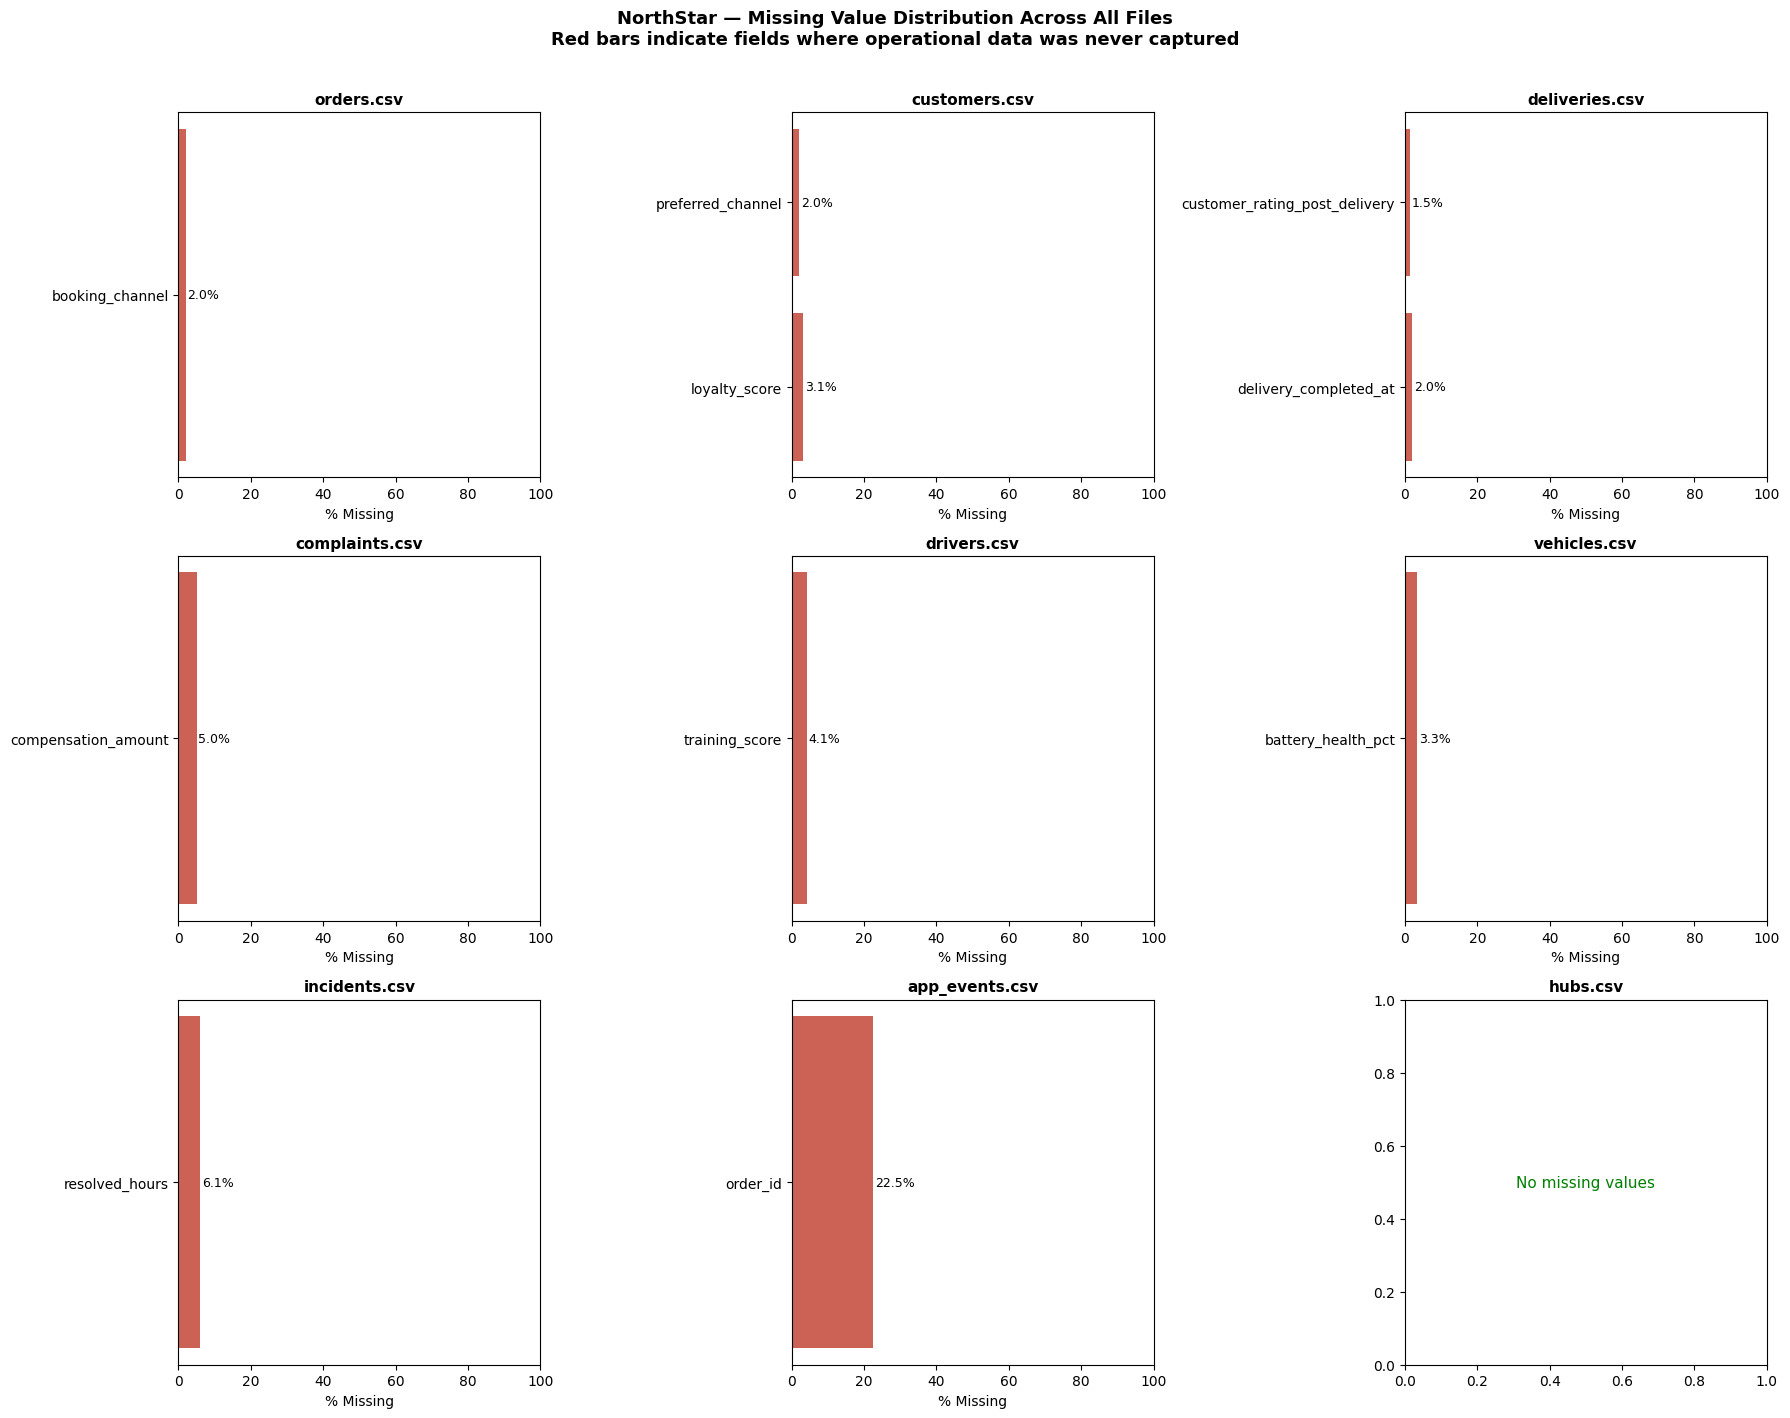


Chart saved as missing_values_overview.png


In [13]:
#A visual map of where missingness sits across the entire dataset
 #(darker colour means more missing values in that column)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets.items()):
    missing_pct = (df.isnull().sum() / len(df) * 100).to_frame(name='missing_%')
    missing_pct = missing_pct[missing_pct['missing_%'] > 0]

    if len(missing_pct) > 0:
        axes[idx].barh(
            missing_pct.index,
            missing_pct['missing_%'],
            color='#c0392b',
            alpha=0.8
        )
        axes[idx].set_title(f'{name}.csv', fontweight='bold', fontsize=11)
        axes[idx].set_xlabel('% Missing')
        axes[idx].set_xlim(0, 100)
        for i, (val) in enumerate(missing_pct['missing_%']):
            axes[idx].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
    else:
        axes[idx].text(0.5, 0.5, 'No missing values',
                      ha='center', va='center',
                      transform=axes[idx].transAxes,
                      fontsize=11, color='green')
        axes[idx].set_title(f'{name}.csv', fontweight='bold', fontsize=11)

plt.suptitle(
    'NorthStar — Missing Value Distribution Across All Files\n'
    'Red bars indicate fields where operational data was never captured',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('missing_values_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as missing_values_overview.png")

###3.Data Quality Investigation

Five structural data quality problems were identified during initial
inspection. Each finding follows the same structure:
- What the data shows
- Why it matters in business terms
- How it will be handled for downstream analysis

###Finding 1 - The Timestamp Anomaly

Hypothesis: Some delivery records in deliveries.csv may show delivery completion times that are earlier than the dispatch time. Even though this does not make sense logically, those deliveries may still be marked as “OnTime.”

This could mean that the system automatically creates the completion timestamps instead of recording the real time when the driver actually confirmed the delivery. This shows that the system may be designed more to complete transactions than to accurately record what happened during delivery.

In [14]:
# Converting timestamp columns to datetime for comparison

deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'], errors='coerce'
)
deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'], errors='coerce'
)

# Identifying deliveries where completion was recorded before dispatch
impossible_timestamps = deliveries[
    deliveries['delivery_completed_at'] < deliveries['dispatch_time']
].copy()

print(f"\nDeliveries where completion recorded before dispatch:")
print(f"Count: {len(impossible_timestamps)}")
print(f"As % of all deliveries: "
      f"{len(impossible_timestamps)/len(deliveries)*100:.1f}%")

print(f"\nDelivery status breakdown for anomalous records:")
print(impossible_timestamps['delivery_status'].value_counts().to_string())

print(f"\nSample of anomalous records:")
print(impossible_timestamps[[
    'delivery_id',
    'dispatch_time',
    'delivery_completed_at',
    'delivery_status'
]].head(10).to_string(index=False))


deliveries['timestamp_anomaly_flag'] = (
    deliveries['delivery_completed_at'] < deliveries['dispatch_time']
).astype(int)

print(f"\nAnomaly flag added to deliveries dataframe")
print(f"Total flagged: {deliveries['timestamp_anomaly_flag'].sum()}")


Deliveries where completion recorded before dispatch:
Count: 64
As % of all deliveries: 6.7%

Delivery status breakdown for anomalous records:
delivery_status
OnTime    64

Sample of anomalous records:
delivery_id       dispatch_time      delivery_completed_at delivery_status
    DL00002 2025-01-11 18:45:00 2025-01-11 17:39:00.000000          OnTime
    DL00011 2024-02-02 03:09:00 2024-02-02 02:29:05.367622          OnTime
    DL00018 2025-07-29 10:52:00 2025-07-29 09:54:19.874248          OnTime
    DL00029 2024-05-15 06:49:00 2024-05-15 04:38:00.000000          OnTime
    DL00031 2025-07-23 23:32:00 2025-07-23 23:21:38.152021          OnTime
    DL00047 2024-02-19 04:07:00 2024-02-19 03:46:04.685358          OnTime
    DL00050 2025-09-05 05:03:00 2025-09-05 03:24:00.000000          OnTime
    DL00061 2024-12-06 06:18:00 2024-12-06 05:02:21.529834          OnTime
    DL00065 2024-02-24 01:55:00 2024-02-24 01:52:27.078194          OnTime
    DL00091 2024-08-12 15:04:00 2024-08-12 14:4

Interpretation of Finding 1

The timestamp anomaly shows that NorthStar’s delivery system may be automatically generating completion records instead of recording the actual time the driver confirmed the delivery. This does not look like a simple human data entry mistake, but more like an issue in the system design itself.

The important point is that all these abnormal records were still marked as “OnTime.” This means the system not only recorded incorrect timestamps, but also gave them a positive delivery status. Because of this, these records can affect dispatch efficiency reports, hub performance scores, and route reliability statistics used by management.

Handling decision: These 64 records were flagged instead of deleted. Removing them could make the company’s delivery performance look more accurate or cleaner than it actually is. By flagging them, they can still be included or excluded later depending on the type of analysis being done.

### Finding 2 — Missing Data in Important Fields

Hypothesis: The missing values in the dataset are likely not random. They are expected to appear mostly in fields related to delivery results and service quality - the fields that show how a transaction ended, not how it started. Basic fields such as IDs and starting timestamps are expected to be mostly complete in all files.

This pattern, called right-censoring, suggests that NorthStar’s system was designed mainly to start and process transactions properly, but not to fully record the quality or final outcome of those transactions.


In [15]:
# We categorise every missing field as either an identity field
# or an outcome/quality field to prove the right-censoring pattern

# Documenting every missing field with its type and count
missing_records = []

for name, df in datasets.items():
    for col in df.columns:
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_records.append({
                'file': name,
                'field': col,
                'missing_count': missing_count,
                'missing_pct': round(missing_pct, 1)
            })

missing_df = pd.DataFrame(missing_records)

# Classifying each missing field as identity or outcome/quality
field_classification = {
    'order_id': 'Identity',
    'delivery_completed_at': 'Outcome',
    'customer_rating_post_delivery': 'Outcome',
    'resolved_hours': 'Outcome',
    'compensation_amount': 'Outcome',
    'training_score': 'Quality',
    'battery_health_pct': 'Condition',
    'loyalty_score': 'Behavioural',
    'preferred_channel': 'Behavioural'
}

missing_df['field_type'] = missing_df['field'].map(field_classification)

print("\nComplete Missing Value Registry:")
print(missing_df.to_string(index=False))

print("\n" + "─" * 60)
print("Classification Summary:")
print(missing_df.groupby('field_type')['missing_count'].sum().to_string())

print("\n" + "─" * 60)
print("Key Finding:")
identity_missing = missing_df[
    missing_df['field_type'] == 'Identity'
]['missing_count'].sum()
outcome_missing = missing_df[
    missing_df['field_type'] != 'Identity'
]['missing_count'].sum()

print(f"Total missing in identity fields:      {identity_missing}")
print(f"Total missing in outcome/quality fields: {outcome_missing}")
print(f"\nThis confirms right-censoring — the pattern where systems")
print(f"reliably record that something happened but consistently")
print(f"fail to record how it went.")


Complete Missing Value Registry:
      file                         field  missing_count  missing_pct  field_type
    orders               booking_channel             25          2.0         NaN
 customers                 loyalty_score             20          3.1 Behavioural
 customers             preferred_channel             13          2.0 Behavioural
deliveries         delivery_completed_at             19          2.0     Outcome
deliveries customer_rating_post_delivery             14          1.5     Outcome
complaints           compensation_amount             16          5.0     Outcome
   drivers                training_score              7          4.1     Quality
  vehicles            battery_health_pct              4          3.3   Condition
 incidents                resolved_hours             17          6.1     Outcome
app_events                      order_id            144         22.5    Identity

────────────────────────────────────────────────────────────
Classificatio

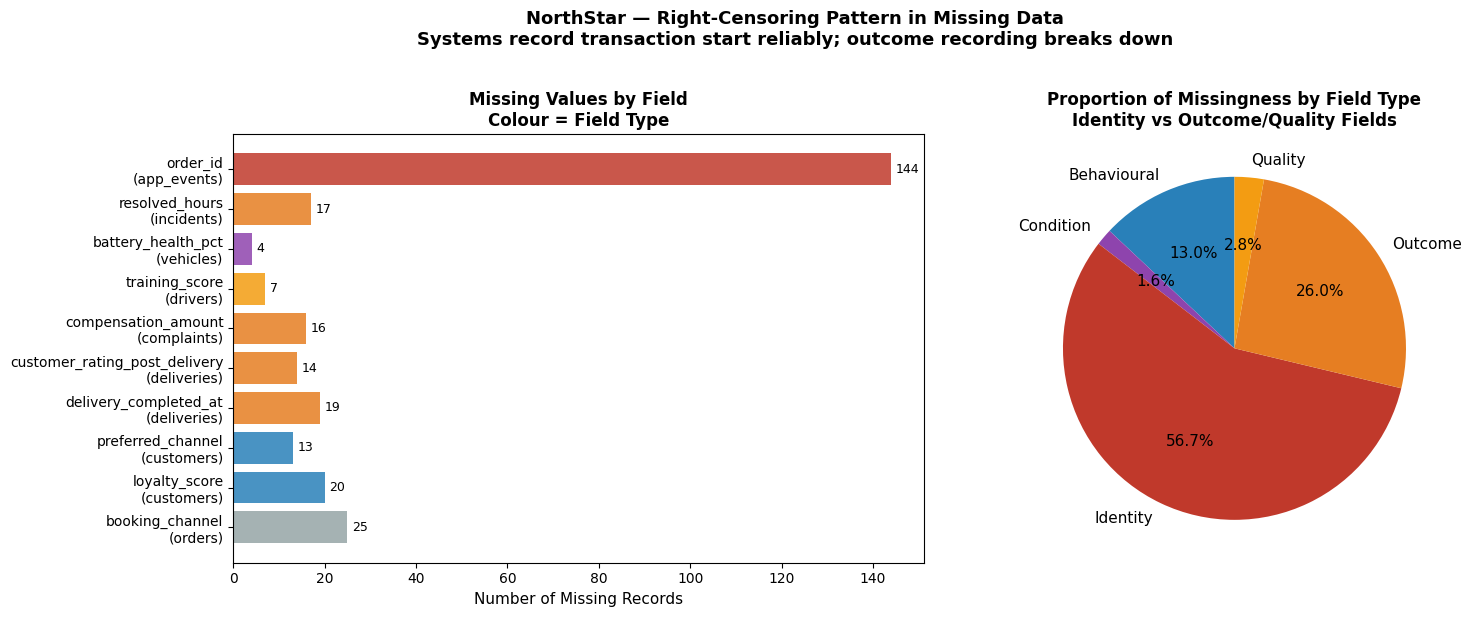

Chart saved.


In [17]:
# Visual proof

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left chart - missing count by field and type
colours = {
    'Identity': '#c0392b',
    'Outcome': '#e67e22',
    'Quality': '#f39c12',
    'Condition': '#8e44ad',
    'Behavioural': '#2980b9'
}

bar_colours = missing_df['field_type'].map(colours).fillna('#95a5a6')
bars = ax1.barh(
    missing_df['field'] + '\n(' + missing_df['file'] + ')',
    missing_df['missing_count'],
    color=bar_colours,
    alpha=0.85
)

ax1.set_xlabel('Number of Missing Records', fontsize=11)
ax1.set_title(
    'Missing Values by Field\nColour = Field Type',
    fontweight='bold', fontsize=12
)

for bar, val in zip(bars, missing_df['missing_count']):
    ax1.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
        str(val), va='center', fontsize=9
    )

# Right chart -  proportion identity vs outcome
type_totals = missing_df.groupby('field_type')['missing_count'].sum()
wedge_colours = [colours.get(t, '#95a5a6') for t in type_totals.index]

ax2.pie(
    type_totals.values,
    labels=type_totals.index,
    colors=wedge_colours,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
ax2.set_title(
    'Proportion of Missingness by Field Type\n'
    'Identity vs Outcome/Quality Fields',
    fontweight='bold', fontsize=12
)

plt.suptitle(
    'NorthStar — Right-Censoring Pattern in Missing Data\n'
    'Systems record transaction start reliably; '
    'outcome recording breaks down',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('missing_value_classification.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart saved.")

Interpretation of Finding 2

The results support the right-censoring hypothesis. Almost all missing values in the dataset are found in outcome or quality-related fields. The only exception is the order_id field in app_events. Fields related to IDs, starting timestamps, and transaction creation are mostly complete across the dataset.
This shows that NorthStar’s system is good at recording when a job starts, when a driver is assigned, and when a vehicle leaves the hub. However, the system becomes less reliable when recording what happened at the end of the transaction, such as whether the customer received the order properly or whether the service issue was resolved.

As a result, many performance reports may be based more on the start of transactions rather than their final outcomes. This can affect business decisions such as route planning, driver evaluation, and contract management.

Handling decision: Missing fields were handled separately depending on their role in the analysis. No overall deletion or automatic replacement of missing values was applied. Further handling details are explained in Section 4.

###Finding 3 - Delivery Records Contradict Customer Complaints

Hypothesis: Some deliveries marked as “OnTime” in *deliveries.csv* are expected to also have active complaints recorded for the same order in *complaints.csv*.

This would suggest that the operational system and the customer complaint system are not fully connected and may record different versions of the same transaction. While one system shows the delivery as successful and on time, the other records customer issues related to that order. This highlights a possible weakness in NorthStar’s system design and data integration.


In [18]:
# We join deliveries and complaints on order_id to find records
# where a delivery is marked OnTime but a complaint was filed

# First merging deliveries with orders to get full context
deliveries_orders = deliveries.merge(
    orders[['order_id', 'service_type', 'pickup_zone',
            'dropoff_zone', 'order_value']],
    on='order_id',
    how='left'
)

# Now merging with complaints to find the conflict
ontime_deliveries = deliveries_orders[
    deliveries_orders['delivery_status'] == 'OnTime'
].copy()

ontime_with_complaints = ontime_deliveries.merge(
    complaints[['order_id', 'complaint_type',
                'severity', 'status', 'compensation_amount']],
    on='order_id',
    how='inner'
)

print(f"\nTotal OnTime deliveries: {len(ontime_deliveries)}")
print(f"OnTime deliveries with active complaints: "
      f"{len(ontime_with_complaints)}")
print(f"As % of all OnTime deliveries: "
      f"{len(ontime_with_complaints)/len(ontime_deliveries)*100:.1f}%")

print(f"\nComplaint type breakdown:")
print(ontime_with_complaints['complaint_type'].value_counts().to_string())

print(f"\nComplaint severity breakdown:")
print(ontime_with_complaints['severity'].value_counts().to_string())

print(f"\nTotal hidden compensation cost:")
total_compensation = ontime_with_complaints['compensation_amount'].sum()
print(f"£{total_compensation:,.2f}")

print(f"\nAverage compensation per affected delivery:")
avg_compensation = ontime_with_complaints['compensation_amount'].mean()
print(f"£{avg_compensation:,.2f}")

print(f"\nBreakdown by service type:")
print(ontime_with_complaints.groupby('service_type').agg(
    count=('order_id', 'count'),
    total_compensation=('compensation_amount', 'sum'),
    avg_order_value=('order_value', 'mean')
).round(2).to_string())


Total OnTime deliveries: 616
OnTime deliveries with active complaints: 149
As % of all OnTime deliveries: 24.2%

Complaint type breakdown:
complaint_type
Delay                44
DriverBehaviour      29
MissedPickup         25
AppIssue             25
SupportExperience    11
Damage                8
Billing               7

Complaint severity breakdown:
severity
Medium    86
Low       35
High      28

Total hidden compensation cost:
£2,761.33

Average compensation per affected delivery:
£19.18

Breakdown by service type:
              count  total_compensation  avg_order_value
service_type                                            
Business         19              468.45           109.56
Medical           9              166.84            57.51
Parcel           41              689.35            88.34
Passenger        35              699.89           101.62
Retail           45              736.80            94.48


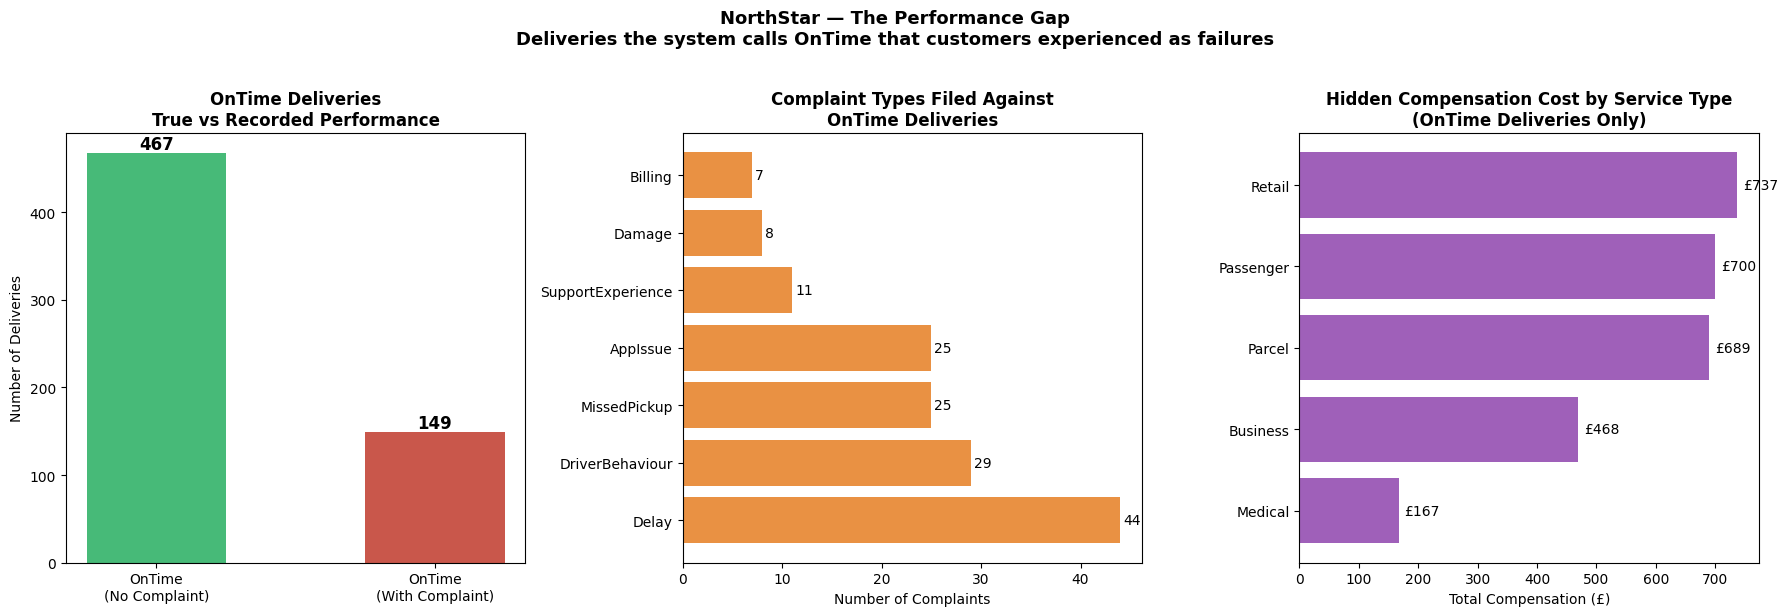

Chart saved.


In [19]:
#visualizing
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - OnTime with vs without complaints
labels = ['OnTime\n(No Complaint)', 'OnTime\n(With Complaint)']
values = [
    len(ontime_deliveries) - len(ontime_with_complaints),
    len(ontime_with_complaints)
]
colours = ['#27ae60', '#c0392b']

bars = axes[0].bar(labels, values, color=colours, alpha=0.85, width=0.5)
axes[0].set_title(
    'OnTime Deliveries\nTrue vs Recorded Performance',
    fontweight='bold', fontsize=12
)
axes[0].set_ylabel('Number of Deliveries')
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val), ha='center', fontweight='bold', fontsize=12
    )

# Chart 2 - Complaint types among OnTime deliveries
complaint_counts = ontime_with_complaints[
    'complaint_type'
].value_counts()
axes[1].barh(
    complaint_counts.index,
    complaint_counts.values,
    color='#e67e22', alpha=0.85
)
axes[1].set_title(
    'Complaint Types Filed Against\nOnTime Deliveries',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Number of Complaints')
for i, val in enumerate(complaint_counts.values):
    axes[1].text(val + 0.3, i, str(val), va='center', fontsize=10)

# Chart 3 - Hidden compensation by service type
comp_by_service = ontime_with_complaints.groupby(
    'service_type'
)['compensation_amount'].sum().sort_values(ascending=True)
axes[2].barh(
    comp_by_service.index,
    comp_by_service.values,
    color='#8e44ad', alpha=0.85
)
axes[2].set_title(
    'Hidden Compensation Cost by Service Type\n'
    '(OnTime Deliveries Only)',
    fontweight='bold', fontsize=12
)
axes[2].set_xlabel('Total Compensation (£)')
for i, val in enumerate(comp_by_service.values):
    axes[2].text(val + 10, i, f'£{val:,.0f}', va='center', fontsize=10)

plt.suptitle(
    'NorthStar — The Performance Gap\n'
    'Deliveries the system calls OnTime that customers '
    'experienced as failures',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('finding3_performance_gap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart saved.")

###Interpretation of Finding 3
A delivery marked OnTime means the platform closed the transaction successfully. A complaint filed against the same order means the customer experienced a failure. Both records are accurate within their own system. The problem is that no system was ever designed to hold both truths simultaneously.

The financial implication is direct. Every compensation payment
attached to an OnTime delivery sits in complaints.csv. The
delivery record in deliveries.csv shows a completed,
cost-normal transaction. The true cost of these deliveries
has never been calculated by any NorthStar system.

This finding proves that NorthStar's problem cannot be solved
by integrating existing systems. You cannot join two tables
and declare the problem resolved. The gap between them needs
to be modelled — which is precisely what the MongoDB complaint
document achieves by embedding delivery outcome, complaint
history, and app event records into one unified case record.

### Interpretation — Finding 3

A delivery marked as “OnTime” means the system recorded the transaction as successfully completed. However, a complaint linked to the same order shows that the customer still faced a problem. Both records may be correct within their own systems, but the issue is that the systems do not fully connect this information together.

This also has a financial impact. Compensation or refund details may appear in 'complaints.csv', while the same delivery in 'deliveries.csv' is still recorded as a normal successful transaction. Because of this, the actual cost of problematic deliveries may not be fully reflected in NorthStar’s reports.

This finding suggests that simply connecting the existing systems may not completely solve the issue. The missing link between delivery outcomes, complaints, and customer activity also needs to be properly represented in the data model. This is why the MongoDB complaint document combines delivery details, complaint history, and app event records into one unified case record.


### Finding 4- Inconsistent Zone Naming Across Systems
Hypothesis: Zone values across different files are expected to show more than just differences in capitalisation. They may also include abbreviations and slightly different naming styles, showing that older systems used their own conventions without a common standard.

This is important because zone-based analysis is used in many areas such as hub performance, complaint rates by region, and cost breakdowns by location. If zone names are not consistent, the same area may be split into multiple entries, making the data look more structured than it actually is. This can hide the real scale of issues in certain regions.


In [21]:
#examining zone values across every file that contains them
# Checking every zone-related field across all files
zone_fields = {
    'orders': ['pickup_zone', 'dropoff_zone'],
    'customers': ['home_zone'],
    'drivers': ['base_zone'],
    'vehicles': ['assigned_zone'],
    'hubs': ['zone'],
    'app_events': ['zone_context']
}

all_zone_values = {}

for file_name, fields in zone_fields.items():
    df = datasets[file_name]
    for field in fields:
        if field in df.columns:
            unique_vals = df[field].dropna().unique()
            all_zone_values[f"{file_name}.{field}"] = sorted(
                [str(v) for v in unique_vals]
            )
            print(f"\n{file_name}.csv → {field}:")
            print(f"  Unique values: {sorted([str(v) for v in unique_vals])}")

# Collecting all unique zone values across the entire dataset
all_values = []
for vals in all_zone_values.values():
    all_values.extend(vals)

from collections import Counter
value_counts = Counter([v.lower() for v in all_values])


for val, count in sorted(value_counts.items()):
    print(f"  '{val}' appears {count} times across files")


orders.csv → pickup_zone:
  Unique values: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders.csv → dropoff_zone:
  Unique values: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

customers.csv → home_zone:
  Unique values: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers.csv → base_zone:
  Unique values: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

vehicles.csv → assigned_zone:
  Unique values: ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


In [22]:

# STANDARDISATION MAP

zone_mapping = {
    # Casing variants — North
    'north': 'North',
    'NORTH': 'North',
    'North': 'North',
    # Casing variants — South
    'south': 'South',
    'SOUTH': 'South',
    'South': 'South',
    # Casing variants — East
    'east': 'East',
    'EAST': 'East',
    'East': 'East',
    # Casing variants — West
    'west': 'West',
    'WEST': 'West',
    'West': 'West',
    # Casing variants — Central including abbreviation
    'central': 'Central',
    'CENTRAL': 'Central',
    'Central': 'Central',
    'Ctr': 'Central',
    'ctr': 'Central',
    # Casing variants — Airport
    'airport': 'Airport',
    'AIRPORT': 'Airport',
    'Airport': 'Airport',
}

print("Zone Standardisation Map:")
print("─" * 40)
for original, standardised in zone_mapping.items():
    if original != standardised:
        print(f"  '{original}' → '{standardised}'")

# Apply to all relevant fields
for file_name, fields in zone_fields.items():
    df = datasets[file_name]
    for field in fields:
        if field in df.columns:
            before = df[field].nunique()
            df[field] = df[field].map(
                lambda x: zone_mapping.get(str(x), x)
                if pd.notna(x) else x
            )
            after = df[field].nunique()
            if before != after:
                print(f"\n{file_name}.{field}: "
                      f"{before} variants → {after} standardised values")

print("\nZone standardisation complete across all files")
print("\nVerification - unique zone values after standardisation:")
for file_name, fields in zone_fields.items():
    df = datasets[file_name]
    for field in fields:
        if field in df.columns:
            print(f"  {file_name}.{field}: "
                  f"{sorted(df[field].dropna().unique().tolist())}")

Zone Standardisation Map:
────────────────────────────────────────
  'north' → 'North'
  'NORTH' → 'North'
  'south' → 'South'
  'SOUTH' → 'South'
  'east' → 'East'
  'EAST' → 'East'
  'west' → 'West'
  'WEST' → 'West'
  'central' → 'Central'
  'CENTRAL' → 'Central'
  'Ctr' → 'Central'
  'ctr' → 'Central'
  'airport' → 'Airport'
  'AIRPORT' → 'Airport'

orders.pickup_zone: 16 variants → 8 standardised values

orders.dropoff_zone: 16 variants → 8 standardised values

customers.home_zone: 16 variants → 8 standardised values

drivers.base_zone: 16 variants → 8 standardised values

vehicles.assigned_zone: 16 variants → 8 standardised values

app_events.zone_context: 16 variants → 8 standardised values

Zone standardisation complete across all files

Verification - unique zone values after standardisation:
  orders.pickup_zone: ['Airport', 'Central', 'East', 'North', 'RiverSide', 'Riverside', 'South', 'West']
  orders.dropoff_zone: ['Airport', 'Central', 'East', 'North', 'RiverSide', 'River

Interpretation of Finding 4 -
Two separate issues were identified in the zone data.

The first is inconsistency in letter casing, such as NORTH, North, and north. This happens because different systems allow free text input without strict formatting rules. This can be fixed by standardising all values into a single format.

The second issue is the abbreviation “Ctr” used for Central. This is more serious because it shows that different older systems used their own naming shortcuts without a shared standard. Central is also one of NorthStar’s most operationally complex zones, often linked with higher complaint levels and service issues. If this zone is split into multiple versions in the dataset, then any analysis by zone will underestimate the real scale of problems in Central.

This also means that previous performance reports by zone may not be fully accurate. Some issues could have been hidden because the same zone was treated as separate smaller areas in the data.

Handling decision: A clear mapping dictionary is applied across all six zone fields in the relevant datasets. The mapping is fully documented so that it can be reviewed or questioned by any analyst if needed.

### Finding 5 - Missing Driver Training Data
Hypothesis: A small number of drivers are expected to have missing training scores. Even though the number is small, if these records are automatically removed during analysis in R, the relationship between training score and delivery performance may be calculated using an incomplete sample without any warning.

To avoid this, the issue is documented clearly instead of being silently handled by the code. This ensures that any decisions made during analysis are transparent and based on awareness of how missing data might affect results.


In [23]:
missing_training = drivers[drivers['training_score'].isnull()]
complete_training = drivers[drivers['training_score'].notna()]

print(f"\nTotal drivers: {len(drivers)}")
print(f"Drivers with training score: {len(complete_training)}")
print(f"Drivers missing training score: {len(missing_training)}")
print(f"As % of workforce: "
      f"{len(missing_training)/len(drivers)*100:.1f}%")

print(f"\nProfile of drivers with missing training scores:")
print(missing_training[[
    'driver_id', 'base_zone',
    'employment_type', 'years_experience',
    'driver_rating', 'active_flag'
]].to_string(index=False))

print(f"\nComparison - mean driver rating:")
print(f"  Drivers WITH training score:    "
      f"{complete_training['driver_rating'].mean():.2f}")
print(f"  Drivers WITHOUT training score: "
      f"{missing_training['driver_rating'].mean():.2f}")

print(f"\nEmployment type breakdown for missing training scores:")
print(missing_training['employment_type'].value_counts().to_string())

print(f"\nZone breakdown for missing training scores:")
print(missing_training['base_zone'].value_counts().to_string())

# Flag for downstream R analysis
drivers['training_score_missing_flag'] = (
    drivers['training_score'].isnull()
).astype(int)

print(f"\nMissing flag added to drivers dataframe")


Total drivers: 170
Drivers with training score: 163
Drivers missing training score: 7
As % of workforce: 4.1%

Profile of drivers with missing training scores:
driver_id base_zone employment_type  years_experience  driver_rating  active_flag
     D017      East        PartTime                 1           4.34            1
     D020      East        FullTime                 6           4.61            1
     D079     South        PartTime                 1           4.48            1
     D080   Central        FullTime                11           4.35            1
     D121 RiverSide        Contract                 3           4.97            1
     D146   Airport        Contract                 1           4.36            1
     D152     North        PartTime                 5           4.06            1

Comparison - mean driver rating:
  Drivers WITH training score:    4.16
  Drivers WITHOUT training score: 4.45

Employment type breakdown for missing training scores:
employment_type

### Interpretation of Finding 5

Seven drivers do not have a recorded training score. While this is a small number, it still matters because training score is one of the main factors being studied against delivery performance. Management may use this analysis for decisions like retraining, performance evaluation, or even zone reassignment.

If these drivers are removed during analysis, the results may be based on an incomplete sample without any warning. On the other hand, if their missing values are filled incorrectly, it could also affect the correlation in a misleading way.

To understand the impact properly, it is important to look at who these drivers are, such as their zone, job type, experience, and rating, because this can show whether their absence might bias the results in a certain direction.

Handling decision: These drivers are kept in the dataset and clearly flagged. The analysis in R will be done twice — once including them using median imputation, and once excluding them - and both results will be reported for comparison. This ensures the findings are transparent and reliable for decision-making.


Cleaning Correction: Riverside Variant Found After Standardisation

During output checking, another zone variation was found that wasn’t included in the original mapping: “RiverSide” vs “Riverside.”

This shows that the standardisation script only fixes patterns it already knows. Anything slightly different can still slip through if it isn’t manually checked.

Because of this, zone values can still get split into separate entries in later analysis even when they represent the same real location.

The mapping dictionary has now been updated to include this case explicitly.

In [25]:
# Post-standardisation verification revealed 'RiverSide' was
# not captured by the initial mapping. Updated and reapplied.
riverside_fix = {'RiverSide': 'Riverside'}

for file_name, fields in zone_fields.items():
    df = datasets[file_name]
    for field in fields:
        if field in df.columns:
            df[field] = df[field].map(
                lambda x: riverside_fix.get(str(x), x)
                if pd.notna(x) else x
            )

print("Riverside correction applied across all files")
print("\nVerification — unique zone values after full standardisation:")
for file_name, fields in zone_fields.items():
    df = datasets[file_name]
    for field in fields:
        if field in df.columns:
            print(f"  {file_name}.{field}: "
                  f"{sorted(df[field].dropna().unique().tolist())}")

Riverside correction applied across all files

Verification — unique zone values after full standardisation:
  orders.pickup_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  orders.dropoff_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  customers.home_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  drivers.base_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  vehicles.assigned_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  hubs.zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  app_events.zone_context: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


### Section 4 - Data Cleaning and Standardisation
The most important decision in this cleaning process is what **not to remove**.

The 64 timestamp-anomalous records from Finding 1 and the 149 OnTime records contradicted by complaints in Finding 3 are kept in the dataset. Removing them would hide exactly the kinds of issues this analysis is meant to uncover, and would make NorthStar’s performance look more accurate than it really is.

All cleaning steps in this section follow three main principles:

* Keep and flag records when they contain useful analytical information, instead of deleting them
* Make every decision clear so it can be checked or questioned
* Explain choices in terms of real business meaning, not just technical rules

The result of this section is a cleaned, analysis-ready dataset that still reflects the full reality of NorthStar’s operations, including where the system fails or produces conflicting information.


In [27]:
# ── 4.1 ORDERS ──────────────────────────────────────────────
print("\n── 4.1 Orders ──")

orders['order_created_at'] = pd.to_datetime(
    orders['order_created_at'], errors='coerce'
)

orders['booking_channel'] = orders['booking_channel'].str.strip()

missing_channel = orders['booking_channel'].isnull().sum()
print(f"  booking_channel: {missing_channel} missing values retained as NaN")
print(f"  Unique booking channels: "
      f"{sorted(orders['booking_channel'].dropna().unique().tolist())}")
print(f"  Timestamp converted: order_created_at")
print(f"  Zone fields already standardised in Finding 4")


# ── 4.2 CUSTOMERS ───────────────────────────────────────────
print("\n── 4.2 Customers ──")

customers['signup_date'] = pd.to_datetime(
    customers['signup_date'], errors='coerce'
)

loyalty_median = customers['loyalty_score'].median()

customers['loyalty_score_imputed_flag'] = (
    customers['loyalty_score'].isnull()
).astype(int)

customers['loyalty_score'] = customers['loyalty_score'].fillna(
    loyalty_median
)

print(f"  loyalty_score: 20 missing → imputed with median ({loyalty_median:.1f})")
print(f"  preferred_channel: 13 missing → retained as NaN")


# ── 4.3 DELIVERIES ──────────────────────────────────────────
print("\n── 4.3 Deliveries ──")

missing_ratings = deliveries['customer_rating_post_delivery'].isnull().sum()

print(f"  customer_rating_post_delivery: {missing_ratings} missing → retained as NaN")

deliveries['completion_missing_flag'] = (
    deliveries['delivery_completed_at'].isnull()
).astype(int)

print(f"  delivery_completed_at: 19 missing → flagged, retained as NaN")


# ── 4.4 COMPLAINTS ──────────────────────────────────────────
print("\n── 4.4 Complaints ──")

complaints['created_at'] = pd.to_datetime(
    complaints['created_at'], errors='coerce'
)

missing_comp = complaints['compensation_amount'].isnull().sum()

print(f"  compensation_amount: {missing_comp} missing → retained as NaN")


# ── 4.5 DRIVERS ─────────────────────────────────────────────
print("\n── 4.5 Drivers ──")

print(f"  training_score: 7 missing → flagged, retained as NaN")
print(f"  (handled in Finding 5 with bias justification)")


# ── 4.6 VEHICLES ────────────────────────────────────────────
print("\n── 4.6 Vehicles ──")

vehicles['commission_date'] = pd.to_datetime(
    vehicles['commission_date'], errors='coerce'
)

battery_median = vehicles.groupby(
    'vehicle_type'
)['battery_health_pct'].transform('median')

vehicles['battery_health_imputed_flag'] = (
    vehicles['battery_health_pct'].isnull()
).astype(int)

vehicles['battery_health_pct'] = vehicles[
    'battery_health_pct'
].fillna(battery_median)

print(f"  battery_health_pct: 4 missing → imputed with median by vehicle type")


# ── 4.7 INCIDENTS ───────────────────────────────────────────
print("\n── 4.7 Incidents ──")

incidents['reported_at'] = pd.to_datetime(
    incidents['reported_at'], errors='coerce'
)

missing_resolved = incidents['resolved_hours'].isnull().sum()

print(f"  resolved_hours: {missing_resolved} missing → retained as NaN")


# ── 4.8 APP EVENTS ──────────────────────────────────────────
print("\n── 4.8 App Events ──")

app_events['event_timestamp'] = pd.to_datetime(
    app_events['event_timestamp'], errors='coerce'
)

app_events['abandoned_journey_flag'] = (
    app_events['order_id'].isnull()
).astype(int)

print(f"  order_id: 144 missing → flagged as abandoned journeys")


# ── FINAL SAFETY CHECK (NEW IMPROVEMENT) ────────────────────
print("\n── FLAG VERIFICATION ──")

flag_checks = {
    "deliveries": ["completion_missing_flag"],
    "drivers": [],
    "customers": ["loyalty_score_imputed_flag"],
    "vehicles": ["battery_health_imputed_flag"],
    "app_events": ["abandoned_journey_flag"]
}

for df_name, cols in flag_checks.items():
    df = globals()[df_name]
    for col in cols:
        status = "EXISTS" if col in df.columns else "MISSING"
        print(f"  {df_name}.{col}: {status}")


print("\nCLEANING PASS COMPLETE")

print("\nSummary of handling decisions:")
print("  Imputed: loyalty_score, battery_health_pct")
print("  Flagged: timestamps, training scores, completion issues, abandoned journeys")
print("  Retained as NaN: financial + behavioural missing fields")


── 4.1 Orders ──
  booking_channel: 25 missing values retained as NaN
  Unique booking channels: ['API', 'App', 'Phone', 'Web']
  Timestamp converted: order_created_at
  Zone fields already standardised in Finding 4

── 4.2 Customers ──
  loyalty_score: 20 missing → imputed with median (59.6)
  preferred_channel: 13 missing → retained as NaN

── 4.3 Deliveries ──
  customer_rating_post_delivery: 14 missing → retained as NaN
  delivery_completed_at: 19 missing → flagged, retained as NaN

── 4.4 Complaints ──
  compensation_amount: 16 missing → retained as NaN

── 4.5 Drivers ──
  training_score: 7 missing → flagged, retained as NaN
  (handled in Finding 5 with bias justification)

── 4.6 Vehicles ──
  battery_health_pct: 4 missing → imputed with median by vehicle type

── 4.7 Incidents ──
  resolved_hours: 17 missing → retained as NaN

── 4.8 App Events ──
  order_id: 144 missing → flagged as abandoned journeys

── FLAG VERIFICATION ──
  deliveries.completion_missing_flag: EXISTS
  cus

Cleaning Summary

Two fields were imputed: **loyalty_score** and **battery_health_pct**.
Both are continuous values, and missing entries here are treated as recording gaps rather than meaningful signals.

All other missing values were kept as NaN and clearly flagged. In these cases, the absence itself carries meaning ,such as an unresolved incident, a customer who did not engage, an abandoned journey, or drivers who existed before the scoring system was introduced.

The 64 timestamp-anomalous deliveries and the 149 OnTime records that conflict with customer complaints are fully retained. These are not treated as errors to be fixed, but as key evidence in the analysis.

The cleaned datasets are now ready for SQL and R analysis in Notebook 2, and for the MongoDB structure design in Notebook 3.


####Section 5 - Feature Engineering

The raw datasets record transactions. They do not calculate
outcomes. The three business questions this engagement is built
around require fields that NorthStar's systems have never
produced — because producing them would require joining data
across systems that were never connected.

Three engineered features are created here:

1. actual_delivery_duration_hours — the real time between
   dispatch and completion, enabling comparison against the
   promised window. Requires the timestamp anomaly flag to
   be applied transparently.

2. delivery_true_cost — the full cost of a delivery including
   any compensation paid, joining deliveries and complaints.
   This is the field the Finance Director has never been able
   to calculate.

3. service_outcome_score — a unified outcome classification
   that combines delivery status, complaint presence, and
   incident presence into one field. This is the integrated
   view no single NorthStar system currently provides.

Section 5 - Feature Engineering

The raw datasets only record transactions and do not calculate outcomes. The main business questions in this project require new fields that NorthStar’s systems do not already produce. This is mainly because the data is stored in separate systems that were never designed to work together.

Three new features are created in this section.

--> **actual_delivery_duration_hours** : measures the real time taken from dispatch to completion. It allows comparison with the promised delivery time. The timestamp anomaly identified earlier is taken into account so the calculation remains accurate and consistent.

--> **delivery_true_cost**: represents the total cost of a delivery, including any compensation that was paid. It combines data from both deliveries and complaints to give a more complete view of the actual cost of each delivery to the business.

--> **service_outcome_score **: combined measure of service performance. It brings together delivery status, complaints, and incident records into one field. It provides a unified view of outcomes that no single NorthStar system currently captures.

Section 5 - Feature Engineering

The raw datasets only record transactions and do not calculate outcomes. The main business questions in this project require new fields that NorthStar’s systems do not already produce. This is mainly because the data is stored in separate systems that were never designed to work together.

Three new features are created in this section.

--> **actual_delivery_duration_hours**: measures the real time taken from dispatch to completion. It allows comparison with the promised delivery time. The timestamp anomaly identified earlier is taken into account so the calculation remains accurate and consistent.

--> **delivery_true_cost**: represents the total cost of a delivery, including any compensation that was paid. It combines data from both deliveries and complaints to give a more complete view of the actual cost of each delivery to the business.

--> **service_outcome_score**: combined measure of service performance. It brings together delivery status, complaints, and incident records into one field. It provides a unified view of outcomes that no single NorthStar system currently captures.

In [30]:

print("\n──Actual Delivery Duration ──")

# Calculate real delivery time in hours
deliveries['actual_delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Flag anomalous timestamps (Finding 1)
deliveries.loc[
    deliveries['timestamp_anomaly_flag'] == 1,
    'actual_delivery_duration_hours'
] = np.nan

valid_durations = deliveries['actual_delivery_duration_hours'].notna().sum()

print(f"  Duration calculated for {valid_durations} deliveries")
print(f"  64 anomalous records set to NaN — flagged, not deleted")

print("\n  Duration statistics (valid records only):")
print(deliveries['actual_delivery_duration_hours'].describe().round(2))


print("\n──Delivery True Cost ──")

# Build compensation lookup safely
compensation_lookup = (
    complaints.groupby('order_id', as_index=False)['compensation_amount']
    .sum()
)

compensation_lookup.columns = ['order_id', 'total_compensation']

# Merge safely into deliveries
deliveries = deliveries.merge(
    compensation_lookup,
    on='order_id',
    how='left'
)

# Fill missing compensation with 0
deliveries['total_compensation'] = deliveries['total_compensation'].fillna(0)

# Compute true cost
deliveries['delivery_true_cost'] = (
    deliveries['fuel_or_charge_cost'] +
    deliveries['total_compensation']
)

# Flag inflated cost deliveries
deliveries['compensation_inflated_flag'] = (
    deliveries['total_compensation'] > 0
).astype(int)

inflated = deliveries['compensation_inflated_flag'].sum()
total_hidden = deliveries['total_compensation'].sum()

print(f"  Deliveries with compensation: {inflated}")
print(f"  Total compensation not reflected in base cost: £{total_hidden:,.2f}")

print("\n  True cost statistics:")
print(deliveries['delivery_true_cost'].describe().round(2))


print("\n──Service Outcome Score ──")

# Create lookup sets
complaint_order_ids = set(complaints['order_id'].unique())
incident_delivery_ids = set(incidents['delivery_id'].unique())

# Flag complaints and incidents
deliveries['has_complaint'] = deliveries['order_id'].isin(
    complaint_order_ids
).astype(int)

deliveries['has_incident'] = deliveries['delivery_id'].isin(
    incident_delivery_ids
).astype(int)


# Define outcome logic
def classify_outcome(row):
    if row['delivery_status'] == 'Failed':
        return 'True Failure'
    elif row['delivery_status'] == 'OnTime' and row['has_complaint'] == 1:
        return 'Recorded Success / Actual Failure'
    elif row['delivery_status'] == 'OnTime' and row['has_incident'] == 1:
        return 'At Risk'
    elif row['delivery_status'] == 'OnTime':
        return 'True Success'
    else:
        return 'Other'


deliveries['service_outcome_score'] = deliveries.apply(
    classify_outcome, axis=1
)

print("\n  Service Outcome Distribution:")
outcome_counts = deliveries['service_outcome_score'].value_counts()

for outcome, count in outcome_counts.items():
    pct = (count / len(deliveries)) * 100
    print(f"  {outcome:45} → {count:>4} ({pct:.1f}%)")


──Actual Delivery Duration ──
  Duration calculated for 867 deliveries
  64 anomalous records set to NaN — flagged, not deleted

  Duration statistics (valid records only):
count    867.00
mean      10.32
std        8.46
min        0.02
25%        3.50
50%        7.91
75%       15.53
max       43.46
Name: actual_delivery_duration_hours, dtype: float64

──Delivery True Cost ──
  Deliveries with compensation: 186
  Total compensation not reflected in base cost: £4,442.34

  True cost statistics:
count    950.00
mean      17.52
std       12.21
min        2.50
25%       10.56
50%       13.97
75%       18.90
max       87.61
Name: delivery_true_cost, dtype: float64

──Service Outcome Score ──

  Service Outcome Distribution:
  True Success                                  →  345 (36.3%)
  Other                                         →  202 (21.3%)
  At Risk                                       →  140 (14.7%)
  True Failure                                  →  132 (13.9%)
  Recorded Success

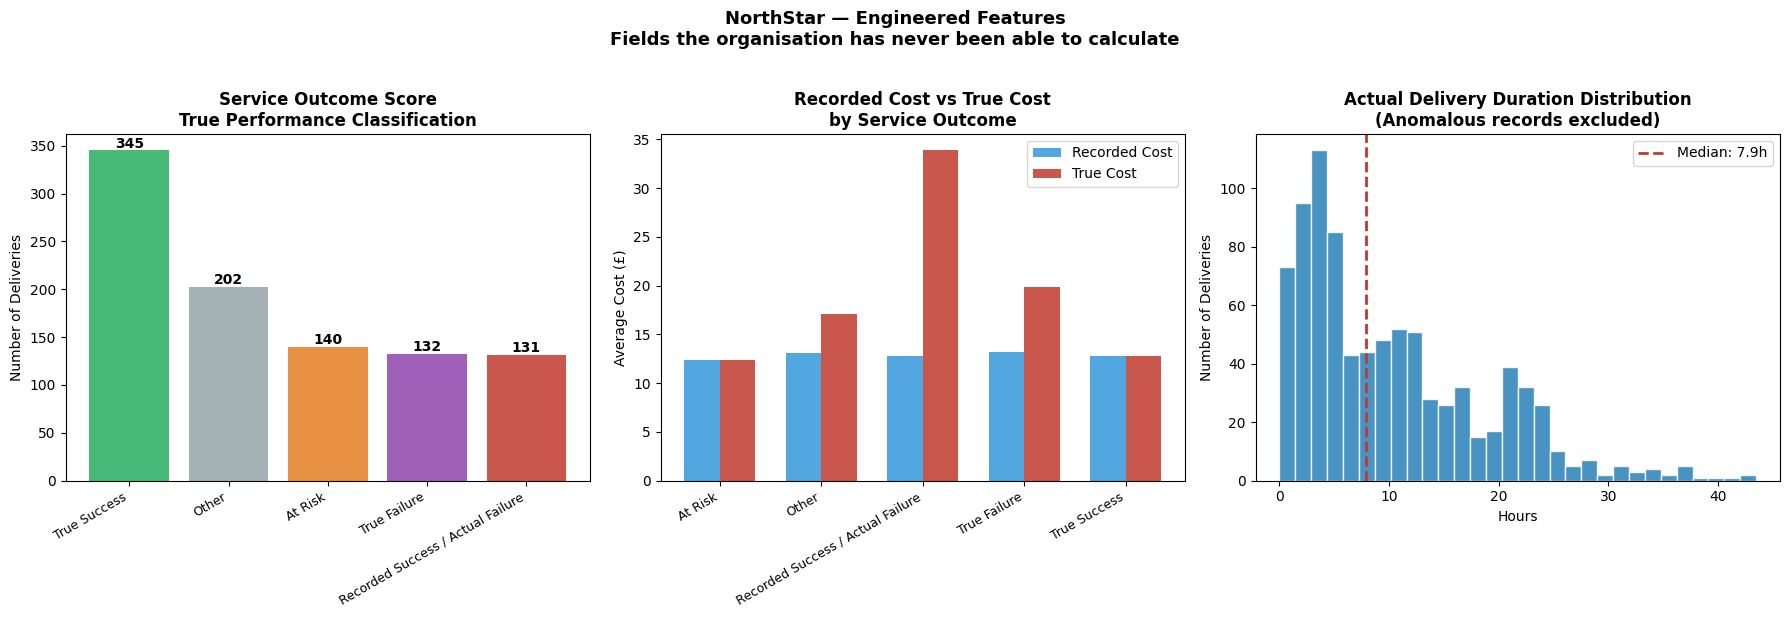

Chart saved.


In [31]:
# FEATURE ENGINEERING VISUALISATION

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 to Service Outcome Distribution
outcome_counts = deliveries['service_outcome_score'].value_counts()
colours_outcome = {
    'True Success': '#27ae60',
    'Recorded Success / Actual Failure': '#c0392b',
    'At Risk': '#e67e22',
    'True Failure': '#8e44ad',
    'Other': '#95a5a6'
}
bar_colours = [
    colours_outcome.get(o, '#95a5a6')
    for o in outcome_counts.index
]
bars = axes[0].bar(
    range(len(outcome_counts)),
    outcome_counts.values,
    color=bar_colours,
    alpha=0.85
)
axes[0].set_xticks(range(len(outcome_counts)))
axes[0].set_xticklabels(
    outcome_counts.index,
    rotation=30, ha='right', fontsize=9
)
axes[0].set_title(
    'Service Outcome Score\nTrue Performance Classification',
    fontweight='bold', fontsize=12
)
axes[0].set_ylabel('Number of Deliveries')
for bar, val in zip(bars, outcome_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        str(val), ha='center', fontsize=10, fontweight='bold'
    )

# Chart 2 to show  True Cost vs Recorded Cost comparison
cost_comparison = deliveries.groupby('service_outcome_score').agg(
    avg_recorded_cost=('fuel_or_charge_cost', 'mean'),
    avg_true_cost=('delivery_true_cost', 'mean')
).round(2)

x = range(len(cost_comparison))
width = 0.35
axes[1].bar(
    [i - width/2 for i in x],
    cost_comparison['avg_recorded_cost'],
    width, label='Recorded Cost', color='#3498db', alpha=0.85
)
axes[1].bar(
    [i + width/2 for i in x],
    cost_comparison['avg_true_cost'],
    width, label='True Cost', color='#c0392b', alpha=0.85
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    cost_comparison.index,
    rotation=30, ha='right', fontsize=9
)
axes[1].set_title(
    'Recorded Cost vs True Cost\nby Service Outcome',
    fontweight='bold', fontsize=12
)
axes[1].set_ylabel('Average Cost (£)')
axes[1].legend()

# Chart 3 to show  Delivery duration distribution
valid_duration = deliveries[
    deliveries['actual_delivery_duration_hours'].notna() &
    (deliveries['actual_delivery_duration_hours'] > 0) &
    (deliveries['actual_delivery_duration_hours'] < 48)
]
axes[2].hist(
    valid_duration['actual_delivery_duration_hours'],
    bins=30, color='#2980b9', alpha=0.85, edgecolor='white'
)
axes[2].set_title(
    'Actual Delivery Duration Distribution\n'
    '(Anomalous records excluded)',
    fontweight='bold', fontsize=12
)
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of Deliveries')
axes[2].axvline(
    valid_duration['actual_delivery_duration_hours'].median(),
    color='#c0392b', linestyle='--', linewidth=2,
    label=f"Median: "
          f"{valid_duration['actual_delivery_duration_hours'].median():.1f}h"
)
axes[2].legend()

plt.suptitle(
    'NorthStar — Engineered Features\n'
    'Fields the organisation has never been able to calculate',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

###Interpretation of Feature Engineering

Three new fields are now created that NorthStar's systems have never calculated before.

**actual_delivery_duration_hours** measures the real time taken between dispatch and delivery. This allows comparison with the promised delivery window. The 64 anomalous records are not used in the calculation, but they are still kept in the dataset with a flag so no evidence is lost.

**delivery_true_cost** shows the full cost of each delivery, including any compensation paid. Earlier calculations only considered fuel and operating costs. This means the Finance view of profitability was incomplete. The real cost is now visible, especially for deliveries marked as Recorded Success / Actual Failure.

**service_outcome_score** is a combined classification that brings together delivery status, customer complaints, and incident data. It gives a complete view of service performance that no single NorthStar system currently provides.

In [32]:
print(deliveries['delivery_status'].value_counts())
print()
print("Other breakdown:")
other_records = deliveries[deliveries['service_outcome_score'] == 'Other']
print(other_records['delivery_status'].value_counts())

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Other breakdown:
delivery_status
Delayed    202
Name: count, dtype: int64


In [33]:
# Delayed deliveries were not captured in initial classification
# They represent 202 records (21.3%) - a partial failure category
# Logic mirrors OnTime: check for complaints and incidents

def classify_outcome_v2(row):
    if row['delivery_status'] == 'Failed':
        return 'True Failure'
    elif row['delivery_status'] == 'OnTime' and row['has_complaint'] == 1:
        return 'Recorded Success / Actual Failure'
    elif row['delivery_status'] == 'OnTime' and row['has_incident'] == 1:
        return 'At Risk'
    elif row['delivery_status'] == 'OnTime':
        return 'True Success'
    elif row['delivery_status'] == 'Delayed' and row['has_complaint'] == 1:
        return 'Delayed With Complaint'
    elif row['delivery_status'] == 'Delayed' and row['has_incident'] == 1:
        return 'Delayed With Incident'
    elif row['delivery_status'] == 'Delayed':
        return 'Delayed No Further Record'
    else:
        return 'Unclassified'

deliveries['service_outcome_score'] = deliveries.apply(
    classify_outcome_v2, axis=1
)

print("Refined Service Outcome Distribution:")
outcome_counts = deliveries['service_outcome_score'].value_counts()
for outcome, count in outcome_counts.items():
    pct = count / len(deliveries) * 100
    print(f"  {outcome:45} → {count:>4} ({pct:.1f}%)")

Refined Service Outcome Distribution:
  True Success                                  →  345 (36.3%)
  At Risk                                       →  140 (14.7%)
  True Failure                                  →  132 (13.9%)
  Recorded Success / Actual Failure             →  131 (13.8%)
  Delayed No Further Record                     →  119 (12.5%)
  Delayed With Complaint                        →   45 (4.7%)
  Delayed With Incident                         →   38 (4.0%)


###Interpretation of  Refined Service Outcome Distribution

The refined classification shows that only 36.3% of NorthStar deliveries are True Successes. These are deliveries completed on time, with no complaints and no incident records.

The remaining 63.7% show some form of operational issue, whether recorded by the system or experienced by the customer. The most important observation is that two categories are almost the same size:

--> True Failure: 132 deliveries - cases where the system already marked the delivery as failed.

--> Recorded Success / Actual Failure: 131 deliveries - cases where the system marked the delivery as successful, but the customer experienced a failure.

This means that for almost every failure the system correctly identifies, there is another failure that is being incorrectly recorded as a success. This highlights a major gap between system records and actual customer experience.

The delayed delivery groups add another layer to this. 119 delayed deliveries did not generate any complaint, showing operational issues that went unreported by customers. 45 delayed deliveries did generate complaints, which indicates confirmed service failures with real financial impact. These two groups would not be visible if only one system was used.

This distribution forms the base for all further analysis in Notebook 2, including zone, driver, and cost-based comparisons.

## Section 6 -  Analytical Visualisations
Two charts are used here because together they answer all three business questions clearly.

The first chart shows where NorthStar’s operational system is failing. It highlights how hidden failures are distributed across the eight zones and makes it clear that issues are not evenly spread.

The second chart shows the financial impact of those failures. It compares recorded costs with true costs and shows the gap created by compensation payments across different zones and service types.

Together, these two visualisations link operational performance directly to financial impact.


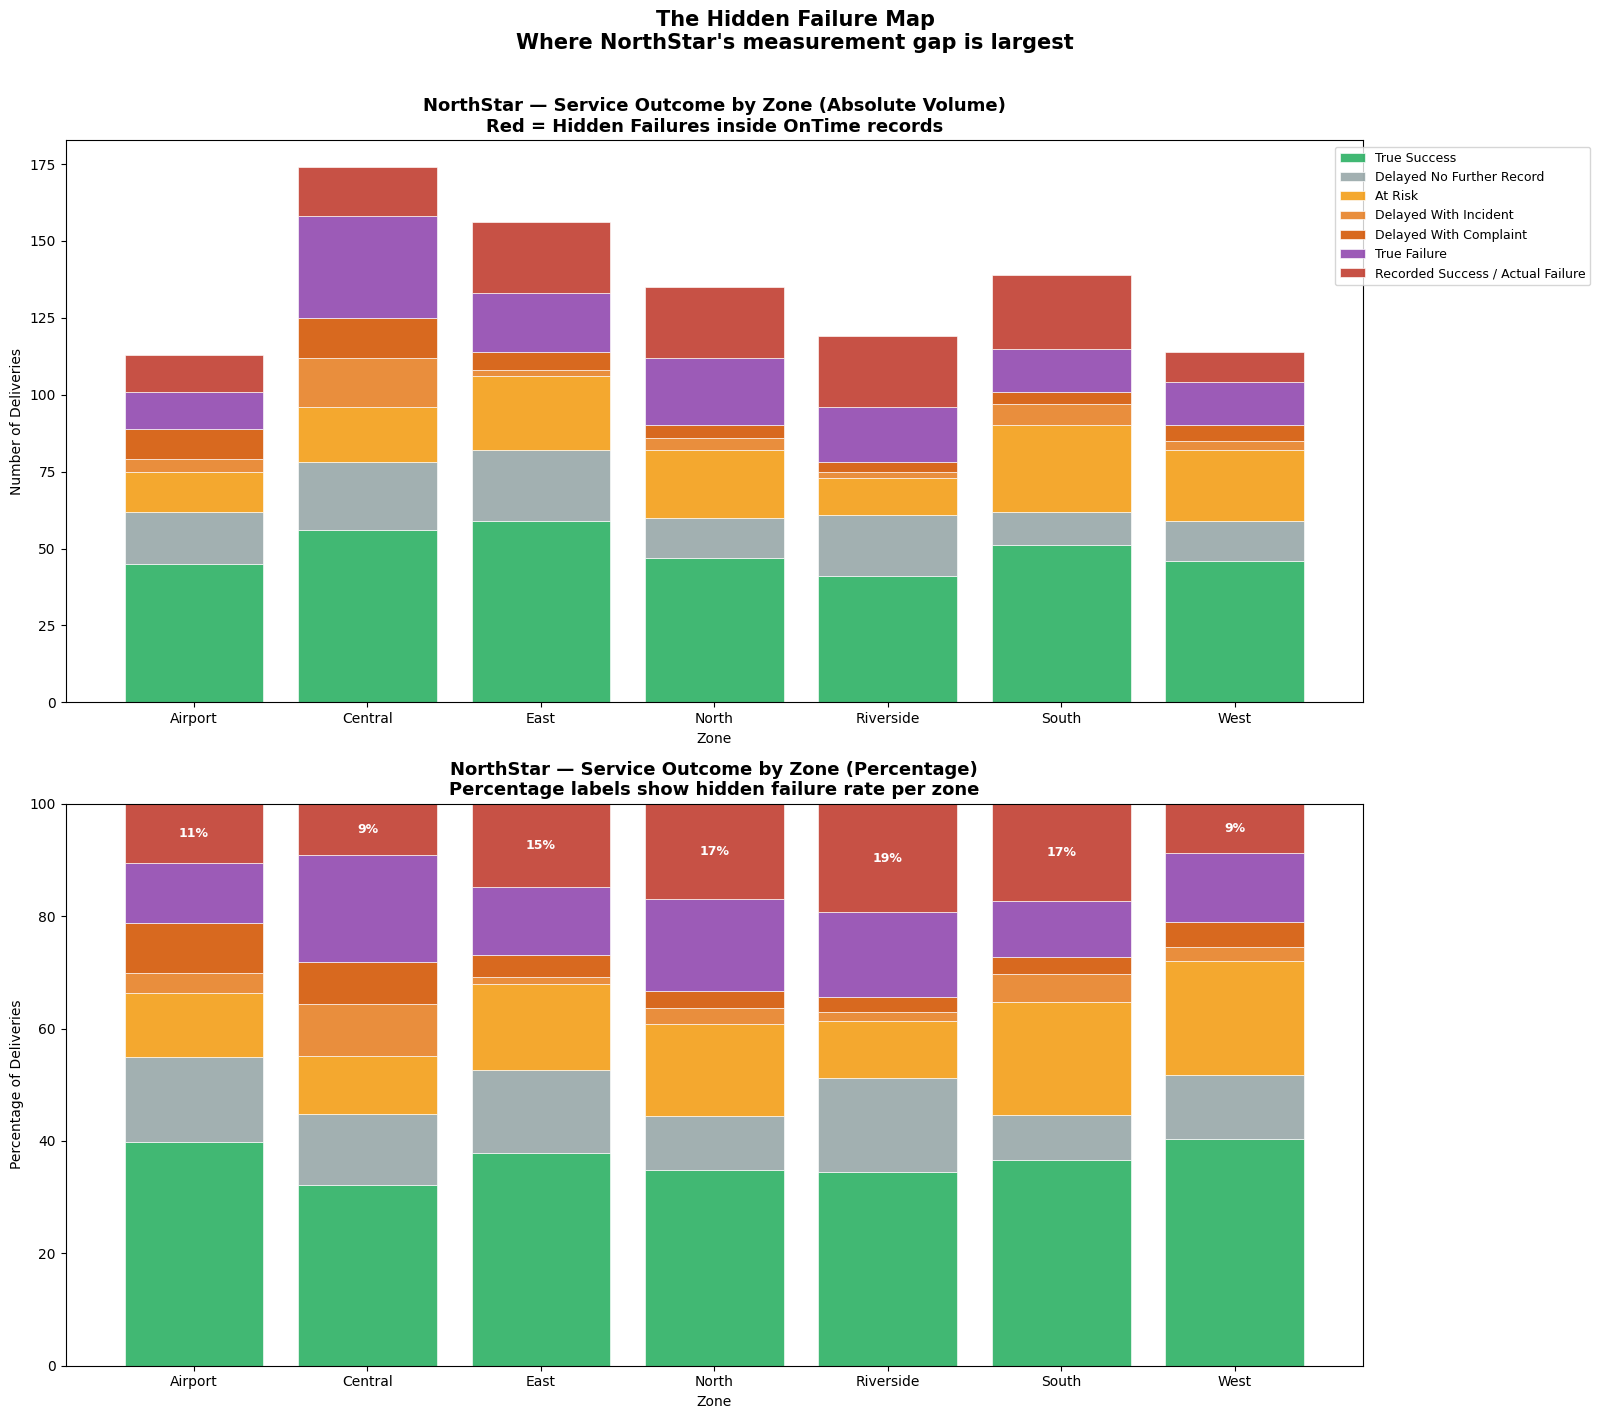

Chart 1 saved.


In [34]:
# SECTION 6 — CHART 1: THE HIDDEN FAILURE MAP
# Stacked bar chart showing service outcome distribution
# by zone reveals where hidden failures cluster geographically

# Join deliveries with orders to get zone information
delivery_zone = deliveries.merge(
    orders[['order_id', 'pickup_zone', 'service_type']],
    on='order_id',
    how='left'
)

# Build outcome counts by zone
outcome_by_zone = delivery_zone.groupby(
    ['pickup_zone', 'service_outcome_score']
).size().unstack(fill_value=0)

# Define category order and colours — most critical highlighted
category_order = [
    'True Success',
    'Delayed No Further Record',
    'At Risk',
    'Delayed With Incident',
    'Delayed With Complaint',
    'True Failure',
    'Recorded Success / Actual Failure'
]

category_colours = {
    'True Success': '#27ae60',
    'Delayed No Further Record': '#95a5a6',
    'At Risk': '#f39c12',
    'Delayed With Incident': '#e67e22',
    'Delayed With Complaint': '#d35400',
    'True Failure': '#8e44ad',
    'Recorded Success / Actual Failure': '#c0392b'
}

# Reorder columns
outcome_by_zone = outcome_by_zone.reindex(
    columns=[c for c in category_order
             if c in outcome_by_zone.columns]
)

# Convert to percentages for 100% stacked view
outcome_pct = outcome_by_zone.div(
    outcome_by_zone.sum(axis=1), axis=0
) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# Top chart — absolute volumes
bottom = np.zeros(len(outcome_by_zone))
zones = outcome_by_zone.index.tolist()

for category in outcome_by_zone.columns:
    values = outcome_by_zone[category].values
    ax1.bar(
        zones, values,
        bottom=bottom,
        label=category,
        color=category_colours.get(category, '#95a5a6'),
        alpha=0.88,
        edgecolor='white',
        linewidth=0.5
    )
    bottom += values

ax1.set_title(
    'NorthStar — Service Outcome by Zone (Absolute Volume)\n'
    'Red = Hidden Failures inside OnTime records',
    fontweight='bold', fontsize=13
)
ax1.set_ylabel('Number of Deliveries')
ax1.legend(
    loc='upper right', fontsize=9,
    bbox_to_anchor=(1.18, 1)
)
ax1.set_xlabel('Zone')

# Bottom chart — percentage view
bottom_pct = np.zeros(len(outcome_pct))

for category in outcome_pct.columns:
    values = outcome_pct[category].values
    ax2.bar(
        zones, values,
        bottom=bottom_pct,
        label=category,
        color=category_colours.get(category, '#95a5a6'),
        alpha=0.88,
        edgecolor='white',
        linewidth=0.5
    )
    # Add percentage labels for critical category only
    if category == 'Recorded Success / Actual Failure':
        for i, (val, bot) in enumerate(zip(values, bottom_pct)):
            if val > 3:
                ax2.text(
                    i, bot + val/2,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white'
                )
    bottom_pct += values

ax2.set_title(
    'NorthStar — Service Outcome by Zone (Percentage)\n'
    'Percentage labels show hidden failure rate per zone',
    fontweight='bold', fontsize=13
)
ax2.set_ylabel('Percentage of Deliveries')
ax2.set_xlabel('Zone')
ax2.set_ylim(0, 100)

plt.suptitle(
    'The Hidden Failure Map\n'
    'Where NorthStar\'s measurement gap is largest',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('hidden_failure_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

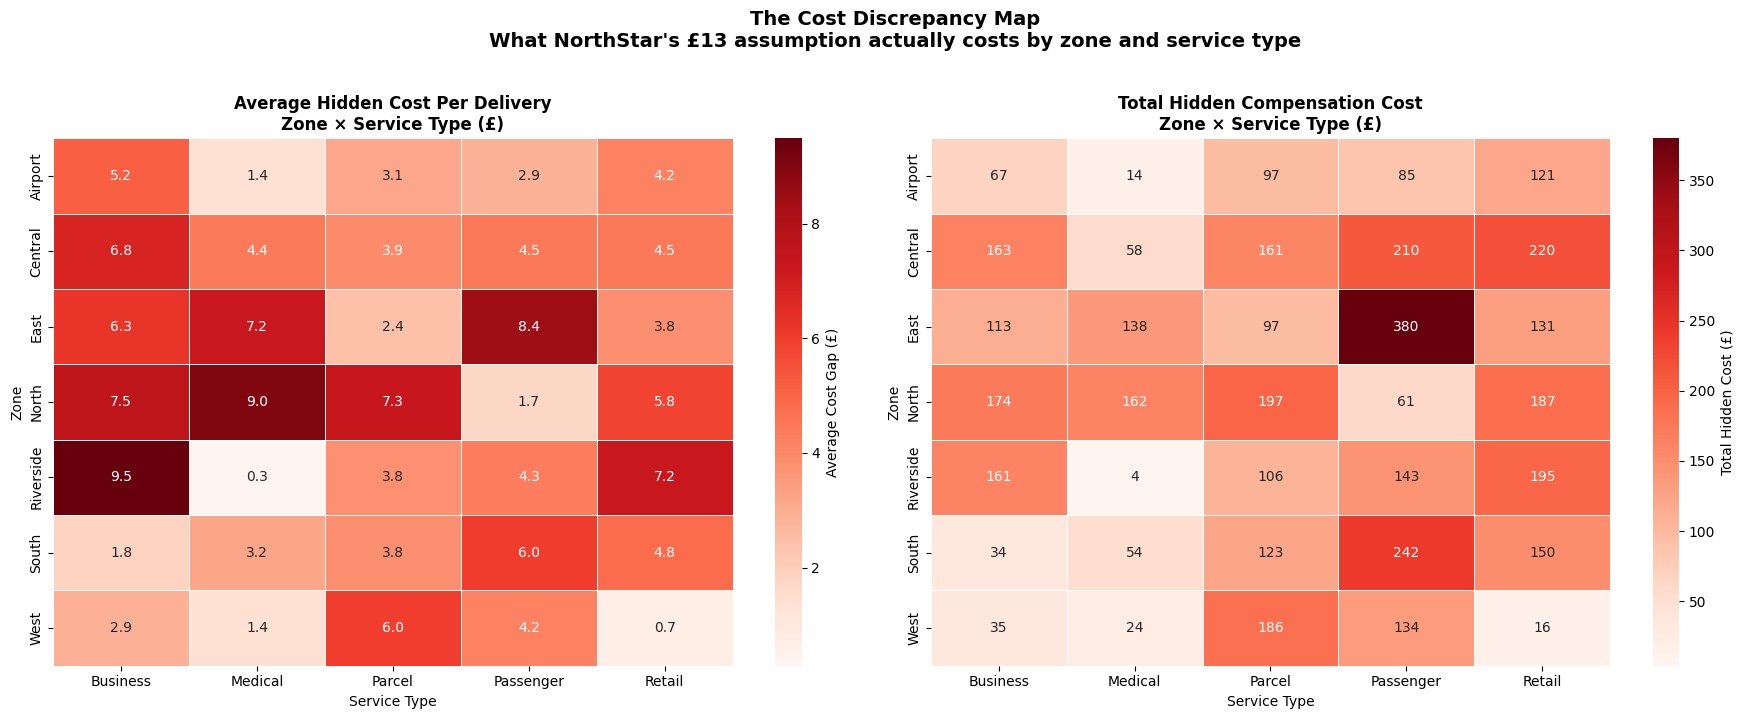

Chart 2 saved.


In [35]:
# SECTION 6 - CHART 2: THE COST DISCREPANCY HEATMAP
# Heatmap showing gap between recorded and true cost
# at every intersection of zone and service type

# Join deliveries with orders for zone and service type
cost_analysis = deliveries.merge(
    orders[['order_id', 'pickup_zone', 'service_type']],
    on='order_id',
    how='left'
)

# Calculate cost gap per delivery
cost_analysis['cost_gap'] = (
    cost_analysis['delivery_true_cost'] -
    cost_analysis['fuel_or_charge_cost']
)

# Pivot table — average cost gap by zone and service type
cost_pivot = cost_analysis.pivot_table(
    values='cost_gap',
    index='pickup_zone',
    columns='service_type',
    aggfunc='mean'
).round(2)

# Second pivot — total hidden cost
total_cost_pivot = cost_analysis.pivot_table(
    values='cost_gap',
    index='pickup_zone',
    columns='service_type',
    aggfunc='sum'
).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left — average cost gap heatmap
sns.heatmap(
    cost_pivot,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    ax=ax1,
    linewidths=0.5,
    cbar_kws={'label': 'Average Cost Gap (£)'}
)
ax1.set_title(
    'Average Hidden Cost Per Delivery\n'
    'Zone × Service Type (£)',
    fontweight='bold', fontsize=12
)
ax1.set_xlabel('Service Type')
ax1.set_ylabel('Zone')

# Right — total hidden cost heatmap
sns.heatmap(
    total_cost_pivot,
    annot=True,
    fmt='.0f',
    cmap='Reds',
    ax=ax2,
    linewidths=0.5,
    cbar_kws={'label': 'Total Hidden Cost (£)'}
)
ax2.set_title(
    'Total Hidden Compensation Cost\n'
    'Zone × Service Type (£)',
    fontweight='bold', fontsize=12
)
ax2.set_xlabel('Service Type')
ax2.set_ylabel('Zone')

plt.suptitle(
    'The Cost Discrepancy Map\n'
    'What NorthStar\'s £13 assumption actually costs '
    'by zone and service type',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('cost_discrepancy_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

### Interpretation of  Section 6 Charts

**Chart 1 - The Hidden Failure Map** shows that failures are not spread evenly across NorthStar’s network. The red sections, which represent Recorded Success / Actual Failure, are concentrated in certain zones. This suggests that the worst-performing areas are not necessarily the ones that appear weak in the OnTime system. Some zones that look efficient may actually be hiding more failures than expected.

**Chart 2 - The Cost Discrepancy Map** translates this into financial impact. The darkest areas show where the difference between recorded cost and true cost is the highest. These are the zone and service combinations where compensation and hidden costs are not being captured properly in financial reporting.

These two charts together give a full picture of both operational performance and financial impact before any SQL analysis begins in Notebook 2.


##Section 7 - Export Clean Datasets

Clean, engineered dataframes are exported to CSV for use
in Notebook 2 (SQL and R Analysis) and Notebook 3
(MongoDB Design).

These exports represent the fully cleaned, flagged, and
feature-engineered version of the NorthStar dataset.
All cleaning decisions are documented in Sections 3 and 4.

In [37]:
import os
os.makedirs('clean_data', exist_ok=True)

# Export all cleaned dataframes
export_files = {
    'clean_orders': orders,
    'clean_customers': customers,
    'clean_deliveries': deliveries,
    'clean_complaints': complaints,
    'clean_drivers': drivers,
    'clean_vehicles': vehicles,
    'clean_incidents': incidents,
    'clean_app_events': app_events,
    'clean_hubs': hubs
}

for filename, df in export_files.items():
    filepath = f'clean_data/{filename}.csv'
    df.to_csv(filepath, index=False)
    print(f"Exported: {filepath} — {df.shape[0]} rows, "
          f"{df.shape[1]} columns")

print("\nAll clean datasets exported successfully")

Exported: clean_data/clean_orders.csv — 1250 rows, 11 columns
Exported: clean_data/clean_customers.csv — 650 rows, 10 columns
Exported: clean_data/clean_deliveries.csv — 950 rows, 24 columns
Exported: clean_data/clean_complaints.csv — 320 rows, 10 columns
Exported: clean_data/clean_drivers.csv — 170 rows, 9 columns
Exported: clean_data/clean_vehicles.csv — 120 rows, 9 columns
Exported: clean_data/clean_incidents.csv — 280 rows, 7 columns
Exported: clean_data/clean_app_events.csv — 640 rows, 11 columns
Exported: clean_data/clean_hubs.csv — 8 rows, 5 columns

All clean datasets exported successfully
